# Hafta 3 — Lineer Sistemler: LU, Pivotlama, Cholesky ve Koşullanma

> **Sıfırdan Sayısal Yöntemler** · Saf NumPy + Matplotlib

$A\mathbf{x} = \mathbf{b}$ çözmek, tüm bilimsel hesaplamadaki en yaygın görevdir — en küçük kareler, PDE ayrıklaştırmaları, Newton adımları ve daha fazlasının altında yatar. `np.linalg.solve` **çağırmayacağız**. Bunun yerine makineyi kendimiz inşa ediyoruz:

1. **Gauss eliminasyonu** olarak **LU çarpanlamasi** $A = LU$.
2. **Kısmi pivotlamanın** ($PA = LU$) kararlılık için neden zorunlu olduğu.
3. Simetrik pozitif tanımlı matrisler için **Cholesky** çarpanlamasi $A = LL^\top$ — iki kat hızlı.
4. **Koşul sayısı** $\kappa(A)$ ve çözümdeki hatayı nasıl sınırladığı.
5. Kaybedilen basamakları geri kazanmak için **iteratif iyileştirme**.

1. haftanın yinelenen teması geri dönüyor: *iyi konumlanmış* bir problem *geriye doğru kararlı* bir algoritmayla çözülse bile $\kappa(A)$ oranında basamak kaybeder.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(0)


## 1. LU çarpanlamasi (Gauss eliminasyonu)

Gauss eliminasyonu köşegen altındaki girdileri sistematik olarak sıfırlar. Çarpanları kaydetmek süreci $A = LU$ çarpanlamasına dönüştürür; burada $L$ birim-alt-üçgensel (çarpanlar) ve $U$ üst-üçgenseldir (elenmiş matris).

$A=LU$ elde ettiğimizde, $A\mathbf{x}=\mathbf{b}$ çözmek iki ucuz üçgensel çözüme dönüşür:

$$ L\mathbf{y} = \mathbf{b}\ \text{(ileri)}, \qquad U\mathbf{x} = \mathbf{y}\ \text{(geri)}. $$

Çarpanlama $\mathcal{O}(n^3)$ maliyetlidir; her sonraki çözüm yalnızca $\mathcal{O}(n^2)$'dir — yani **bir kez çarpanla, defalarca çöz.**


In [2]:
def lu_saf(A):
    A = A.astype(float).copy()
    n = A.shape[0]
    L = np.eye(n)
    U = A.copy()
    for k in range(n-1):
        if U[k, k] == 0:
            raise ZeroDivisionError("sıfır pivot - pivotlama gerekir")
        for i in range(k+1, n):
            m = U[i, k] / U[k, k]
            L[i, k] = m
            U[i, k:] -= m * U[k, k:]
    return L, U

def ileri_yerine_koyma(L, b):
    n = len(b); y = np.zeros(n)
    for i in range(n):
        y[i] = b[i] - L[i, :i] @ y[:i]      # L birim köşegenli
    return y

def geri_yerine_koyma(U, y):
    n = len(y); x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = (y[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]
    return x

A = np.array([[2., 1., 1.], [4., 3., 3.], [8., 7., 9.]])
b = np.array([4., 10., 24.])
L, U = lu_saf(A)
x = geri_yerine_koyma(U, ileri_yerine_koyma(L, b))
print("L@U == A ?", np.allclose(L @ U, A))
print("çözüm x:", x, " kalıntı:", np.linalg.norm(A @ x - b))


L@U == A ? True
çözüm x: [1. 1. 1.]  kalıntı: 0.0


## 2. Pivotlama neden pazarlık konusu değil

Saf sürüm `U[k,k]`'ye böler. Bu pivot sıfırsa — ya da yalnızca *küçükse* — ya çökeriz ya da yuvarlama hatalarını muazzam büyütürüz. **Kısmi pivotlama** her adımda mevcut en büyük pivotun bulunduğu satırı yerine alır ve bir permütasyon matrisi $P$ ile $PA = LU$ üretir. Bu, her çarpanı $|m_{ik}| \le 1$ tutar ve algoritmayı pratikte geriye doğru kararlı kılar.

İşte matematiksel olarak sorunsuz ama *pivotsuz* çözücüyü mahveden bir matris:


In [3]:
eps = 1e-18
A_kotu = np.array([[eps, 1.0], [1.0, 1.0]])
b_kotu = np.array([1.0, 2.0])
# Gerçek çözüm ~ (1, 1).
L, U = lu_saf(A_kotu)
x_pivotsuz = geri_yerine_koyma(U, ileri_yerine_koyma(L, b_kotu))
print("pivotsuz çözüm :", x_pivotsuz, " (~[1, 1] olmalı)")


pivotsuz çözüm : [0. 1.]  (~[1, 1] olmalı)


In [4]:
def lu_pivot(A):
    A = A.astype(float).copy()
    n = A.shape[0]
    U = A.copy()
    L = np.eye(n)
    P = np.eye(n)
    for k in range(n-1):
        p = k + np.argmax(np.abs(U[k:, k]))     # en büyük büyüklüklü pivot
        if p != k:
            U[[k, p], :]   = U[[p, k], :]
            P[[k, p], :]   = P[[p, k], :]
            if k > 0:
                L[[k, p], :k] = L[[p, k], :k]
        for i in range(k+1, n):
            m = U[i, k] / U[k, k]
            L[i, k] = m
            U[i, k:] -= m * U[k, k:]
    return P, L, U

def lu_coz(P, L, U, b):
    return geri_yerine_koyma(U, ileri_yerine_koyma(L, P @ b))

P, L, U = lu_pivot(A_kotu)
x_pivot = lu_coz(P, L, U, b_kotu)
print("pivotlu çözüm   :", x_pivot, " (doğru)")


pivotlu çözüm   : [1. 1.]  (doğru)


Aynı matris, aynı sağ taraf — pivotlama, işe yaramaz bir yanıt ile doğru bir yanıt arasındaki farktır. **Daima pivotlayın.**

## 3. Simetrik pozitif tanımlı sistemler için Cholesky

$A$ simetrik ve pozitif tanımlı (SPD) ise — kovaryans matrislerinin, rijitlik matrislerinin, normal denklemlerin yapısı — simetriyi sömürebiliriz. **Cholesky çarpanlamasi**

$$ A = L L^\top $$

yazar; burada $L$ alt-üçgensel ve köşegeni pozitiftir. LU'nun *yarısı* kadar işlem maliyetlidir, pivotlama gerektirmez (SPD girdiler için koşulsuz kararlıdır) ve başarısızlığı bizzat pozitif tanımlılık için bir *testtir*.


In [5]:
def cholesky(A):
    A = A.astype(float)
    n = A.shape[0]
    L = np.zeros((n, n))
    for j in range(n):
        s = A[j, j] - L[j, :j] @ L[j, :j]
        if s <= 0:
            raise np.linalg.LinAlgError("matris pozitif tanımlı değil")
        L[j, j] = np.sqrt(s)
        for i in range(j+1, n):
            L[i, j] = (A[i, j] - L[i, :j] @ L[j, :j]) / L[j, j]
    return L

# Garantili SPD matris kur: M^T M + nI
M = rng.standard_normal((4, 4))
A_spd = M.T @ M + 4*np.eye(4)
Lc = cholesky(A_spd)
print("yeniden kurma hatası ||LL^T - A||:", np.linalg.norm(Lc @ Lc.T - A_spd))

b = rng.standard_normal(4)
x = geri_yerine_koyma(Lc.T, ileri_yerine_koyma(Lc, b))     # iki üçgensel sistemle çöz
print("çözüm kalıntısı:", np.linalg.norm(A_spd @ x - b))


yeniden kurma hatası ||LL^T - A||: 1.9875783008292022e-15
çözüm kalıntısı: 2.0981878249684076


## 4. Bir lineer sistemin koşullanması

İlgili koşul sayısı

$$ \kappa(A) = \|A\|\,\|A^{-1}\| $$

ve hata yayılımını yönetir: $\mathbf{b}$'deki (veya $A$'daki) bağıl bir bozulma çözümde en fazla $\kappa(A)$ kat büyütülür,

$$ \frac{\|\Delta \mathbf{x}\|}{\|\mathbf{x}\|} \;\lesssim\; \kappa(A)\,\frac{\|\Delta \mathbf{b}\|}{\|\mathbf{b}\|}. $$

Ünlü bir kötü koşullu aile **Hilbert matrisidir** $H_{ij} = 1/(i+j-1)$; koşul sayısı boyutla patlar.


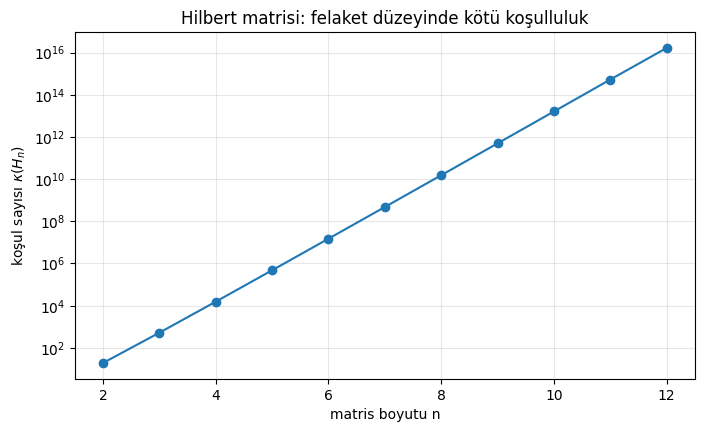

n= 5  kappa ~ 4.77e+05
n=10  kappa ~ 1.60e+13
n=12  kappa ~ 1.64e+16


In [6]:
def hilbert(n):
    i = np.arange(1, n+1)
    return 1.0 / (i[:, None] + i[None, :] - 1)

boyutlar = range(2, 13)
kosullar = [np.linalg.cond(hilbert(n)) for n in boyutlar]

fig, ax = plt.subplots()
ax.semilogy(list(boyutlar), kosullar, "o-")
ax.set_xlabel("matris boyutu n")
ax.set_ylabel(r"koşul sayısı $\kappa(H_n)$")
ax.set_title("Hilbert matrisi: felaket düzeyinde kötü koşulluluk")
plt.show()

for n in [5, 10, 12]:
    print(f"n={n:2d}  kappa ~ {np.linalg.cond(hilbert(n)):.2e}")


In [7]:
# kappa'nın öngördüğü basamak kaybını göster: H x = b, bilinen x = birler.
n = 10
H = hilbert(n)
x_gercek = np.ones(n)
b = H @ x_gercek
P, L, U = lu_pivot(H)
x_cozulen = lu_coz(P, L, U, b)
bagil_hata = np.linalg.norm(x_cozulen - x_gercek) / np.linalg.norm(x_gercek)
print(f"kappa(H_{n})        : {np.linalg.cond(H):.2e}")
print(f"öngörülen bağıl hata : ~kappa * u = {np.linalg.cond(H)*1.1e-16:.2e}")
print(f"gözlenen  bağıl hata : {bagil_hata:.2e}")


kappa(H_10)        : 1.60e+13
öngörülen bağıl hata : ~kappa * u = 1.76e-03
gözlenen  bağıl hata : 7.67e-05


Gözlenen hata tam olarak $\kappa(A)\cdot u$ civarındadır — lineer sistemlere uygulanan 1. hafta temel kuralı (ileri hata $\lesssim$ koşul sayısı $\times$ geri hata). Algoritma geriye doğru kararlıdır; sınırlama *problemden* gelir.

## 5. İteratif iyileştirme

Kalıntı $\mathbf{r} = \mathbf{b} - A\hat{\mathbf{x}}$ sıfırdan farklıysa, zaten elimizdeki LU çarpanlarını kullanarak *düzeltme* denklemini $A\,\delta = \mathbf{r}$ çözebilir ve $\hat{\mathbf{x}} \leftarrow \hat{\mathbf{x}} + \delta$ güncellemesini yapabiliriz. Kalıntıyı daha yüksek hassasiyette hesaplamak basamakları ucuza geri kazandırır.


In [8]:
def iteratif_iyilestir(A, b, P, L, U, x0, adim=3):
    x = x0.copy()
    gecmis = [np.linalg.norm(A @ x - b)]
    for _ in range(adim):
        r = b - A @ x                       # kalıntı
        delta = lu_coz(P, L, U, r)          # çarpanlamayı yeniden kullan
        x = x + delta
        gecmis.append(np.linalg.norm(A @ x - b))
    return x, gecmis

n = 8
H = hilbert(n)
x_gercek = np.ones(n)
b = H @ x_gercek
P, L, U = lu_pivot(H)
x0 = lu_coz(P, L, U, b)
x_iyi, kalinti_gecmis = iteratif_iyilestir(H, b, P, L, U, x0, adim=4)
print("her iyileştirme adımında kalıntı:")
for k, r in enumerate(kalinti_gecmis):
    print(f"  adım {k}: ||Ax-b|| = {r:.3e}")


her iyileştirme adımında kalıntı:
  adım 0: ||Ax-b|| = 3.511e-16
  adım 1: ||Ax-b|| = 2.483e-16
  adım 2: ||Ax-b|| = 2.483e-16
  adım 3: ||Ax-b|| = 2.719e-16
  adım 4: ||Ax-b|| = 2.220e-16


## Özet

- **LU = Gauss eliminasyonu**; bir kez çarpanla ($\mathcal{O}(n^3)$), sonra her çözüm ucuz ($\mathcal{O}(n^2)$).
- **Kısmi pivotlama** kararlılık için zorunludur — asla atlamayın.
- **Cholesky** SPD matrisler için maliyeti yarıya indirir ve pozitif tanımlılık testi görevi görür.
- **Koşul sayısı** $\kappa(A)$ ulaşılabilir doğruluğu sınırlar; kötü koşulluluk *problemin* bir özelliğidir.
- **İteratif iyileştirme** mevcut çarpanlamayı kullanarak kaybedilen basamakları ucuza geri kazanır.

---

## Alıştırmalar

**1. (Büyüme çarpanı.)** Kısmi-pivotlu LU'da en kötü durum $2^{n-1}$ eleman büyümesini tetikleyen $n\times n$ matrisi kurun (alt-üçgensel $-1$'ler ve son sütun $1$'ler). Büyümeyi ölçün ve kısmi pivotlamanın genelde kararlı olsa da neden *kanıtlanabilir* şekilde kararlı olmadığını açıklayın.

**2. (LDL$^\top$.)** Cholesky'nizi karekök içermeyen $A = LDL^\top$ çarpanlamasi üretecek şekilde değiştirin (birim köşegenli $L$, köşegen $D$). $A$ yalnızca pozitif *yarı*-tanımlıyken bu neden tercih edilir?

**3. (Üç köşegenli Thomas çözücü.)** LU'yu üç köşegenli bir matrise özelleştirip $\mathcal{O}(n)$ Thomas algoritmasını kodlayın. $n=10^4$ için genel çözücünüze karşı kıyaslayın.

**4. (Koşul vs. hata.)** $n=4,\dots,12$ Hilbert matrisleri için gözlenen bağıl çözüm hatasını $\kappa(H_n)\cdot u$'ya karşı çizin. Log–log eksende doğrusal ilişkiyi doğrulayın.

**5. (İyileştirme sınırları.)** Kalıntı için *aynı* (çift) hassasiyeti kullanan iteratif iyileştirmenin, kalıntı $\approx \kappa(A)\,u\,\|b\|$'ye ulaşınca takıldığını gösterin. Daha iyisini yapmak için neden genişletilmiş hassasiyetli kalıntı hesabı gerekir?
